Step 1 - setup and feature extraction

In [ ]:
# --- IMPORTS & DEVICE ---
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.models.resnet import resnet18
from torch.utils.data import DataLoader, Subset
from collections import OrderedDict
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
EMBEDDINGS_PATH = 'cifar10_simclr_embeddings.pt'

Using device: cuda


In [57]:
# typiclust algorithm
budgets = [10, 20, 30, 40, 50, 60]
initial_laballed_list = []
all_typical_ids = {}


data = torch.load(EMBEDDINGS_PATH, weights_only=False)
all_features_normalized = np.array([x.numpy() if torch.is_tensor(x) else x for x in data['features']])
all_labels = np.array([x.item() if torch.is_tensor(x) else x for x in data['labels']])

for total_budget in budgets:
  print(f"finding typical images for budget: {total_budget}")

  if total_budget <= 50:
    k_means_algorithm = KMeans(n_clusters=total_budget, random_state=42, n_init='auto')
  else: 
    k_means_algorithm = MiniBatchKMeans(n_clusters=total_budget, random_state=42, n_init='auto')


  cluster_assignments = k_means_algorithm.fit_predict(all_features_normalized)

  if len(initial_laballed_list) != 0:
    covered_clusters = set(cluster_assignments[initial_laballed_list])
  else:
    covered_clusters = set()

  all_clusters = set()
  for i in range(total_budget):
    all_clusters.add(i)

  uncovered_clusters = list(all_clusters - covered_clusters)

  # sort the uncovered clusters by highest density
  uncovered_density = []
  for cluster in uncovered_clusters:
    size = np.sum(cluster_assignments == cluster)
    uncovered_density.append((cluster, size))

  uncovered_density.sort(key=lambda x: x[1], reverse=True)

  needed_new = total_budget - len(initial_laballed_list)
  final_clusters = []
  limit = min(needed_new, len(uncovered_density))

  for i in range(limit):
    cluster_id = uncovered_density[i][0]
    final_clusters.append(cluster_id)


  # --------- typiclust --------------
  nearest = NearestNeighbors(algorithm='brute', n_jobs=-1)

  final_typical_images = []

  for i in final_clusters:
    cluster_i = np.where(cluster_assignments == i)[0]
    cluster_features = all_features_normalized[cluster_i]

    cluster_size = min(20, len(cluster_features))

    if cluster_size <= 1:
        best_id = cluster_i[0]
    else:
      nearest.set_params(n_neighbors=cluster_size)
      nearest.fit(cluster_features)
      distance, indicies = nearest.kneighbors(cluster_features)


      average_distances = distance.mean(axis=1)

      typicality_score = 1 / (average_distances + 1e-8)

      best = np.argmax(typicality_score)

      best_id = cluster_i[best]

    final_typical_images.append(int(best_id))

    print(f"Budget {total_budget} | Cluster {i} winner: Image #{best_id}")

  final_list = initial_laballed_list + final_typical_images
  all_typical_ids[total_budget] = list(final_list)

  print("All done!")

finding typical images for budget: 10
Budget 10 | Cluster 0 winner: Image #9162
Budget 10 | Cluster 7 winner: Image #17387
Budget 10 | Cluster 1 winner: Image #42315
Budget 10 | Cluster 4 winner: Image #9178
Budget 10 | Cluster 6 winner: Image #18668
Budget 10 | Cluster 8 winner: Image #22589
Budget 10 | Cluster 3 winner: Image #12071
Budget 10 | Cluster 9 winner: Image #30798
Budget 10 | Cluster 2 winner: Image #40502
Budget 10 | Cluster 5 winner: Image #18573
All done!
finding typical images for budget: 20
Budget 20 | Cluster 13 winner: Image #18668
Budget 20 | Cluster 9 winner: Image #30798
Budget 20 | Cluster 1 winner: Image #16995
Budget 20 | Cluster 16 winner: Image #9178
Budget 20 | Cluster 18 winner: Image #28657
Budget 20 | Cluster 8 winner: Image #2145
Budget 20 | Cluster 14 winner: Image #37361
Budget 20 | Cluster 10 winner: Image #12943
Budget 20 | Cluster 2 winner: Image #30397
Budget 20 | Cluster 19 winner: Image #23817
Budget 20 | Cluster 7 winner: Image #32109
Budget 20

In [58]:
# linear classficiation model
# this needs to be for 10, 20, 30, 40, 50, 60 

accuracies = []

# initialise encoder
encoder = resnet18()
encoder.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
encoder.maxpool = nn.Identity()
encoder.fc = nn.Identity()
encoder.to(device)


test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=512, shuffle=False)



for budget in budgets:
    print(f"Testing the model with the {budget} typical images...")
    ids_for_this_budget = all_typical_ids[budget]


    X_train_numpy = all_features_normalized[ids_for_this_budget]
    y_train_numpy = all_labels[ids_for_this_budget]

    X_train = torch.tensor(X_train_numpy, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train_numpy, dtype=torch.long).to(device)

    classifier = nn.Linear(512, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        classifier.parameters(), 
        lr=2.5, 
        momentum=0.9, 
        nesterov=True,
        weight_decay=0
    )

    epochs = 200
    classifier.train()



    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = classifier(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()


    clean_weights = torch.load('cifar10_simclr_cleaned.pth', map_location=device, weights_only=True)
    missing, unexpected = encoder.load_state_dict(clean_weights, strict=False)
    encoder.eval()
    classifier.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            features = encoder(images)
    
            features = F.normalize(features, p=2, dim=1)
            
        
            outputs = classifier(features)
        
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    final_accuracy = 100 * correct / total

    accuracies.append(final_accuracy)
    print(f"Accuracy for {budget} labels: {final_accuracy:.2f}%")


print(f"\n results recorded: {accuracies}")

Files already downloaded and verified


c:\Users\arnav\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Testing the model with the 10 typical images...
Accuracy for 10 labels: 50.46%
Testing the model with the 20 typical images...
Accuracy for 20 labels: 56.32%
Testing the model with the 30 typical images...
Accuracy for 30 labels: 73.31%
Testing the model with the 40 typical images...
Accuracy for 40 labels: 74.89%
Testing the model with the 50 typical images...
Accuracy for 50 labels: 78.15%
Testing the model with the 60 typical images...
Accuracy for 60 labels: 79.81%

 results recorded: [50.46, 56.32, 73.31, 74.89, 78.15, 79.81]


random baseline test

In [59]:
import numpy as np
import random

seeds = [100, 200, 250, 130, 302]
budgets = [10, 20, 30, 40, 50, 60]
all_random_ids = {b: {} for b in budgets}


all_indices = list(range(len(all_labels)))

for total_budget in budgets:
    for seed in seeds:
        random.seed(seed)
        random_sample = random.sample(all_indices, total_budget)
        all_random_ids[total_budget][seed] = random_sample

print(f"Budgets captured: {list(all_random_ids)}")

Budgets captured: [10, 20, 30, 40, 50, 60]


In [60]:
random_accuracies_linear = []

for budget in budgets:
    current_budget_accuracy = []
    for seed in seeds:
        ids = all_random_ids[budget][seed]

        
        X_train = torch.tensor(all_features_normalized[ids], dtype=torch.float32).to(device)
        y_train = torch.tensor(all_labels[ids], dtype=torch.long).to(device)
        
    
        classifier = nn.Linear(512, 10).to(device)
        optimizer = optim.SGD(
            classifier.parameters(), 
            lr=2.5, 
            momentum=0.9, 
            nesterov=True,
            weight_decay=0
        )

    
        classifier.train()
        for epoch in range(200):
            optimizer.zero_grad()
            outputs = classifier(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()
            

        classifier.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                features = encoder(images)

                features = torch.nn.functional.normalize(features, p=2, dim=1)

                outputs = classifier(features)

                _, pred = torch.max(outputs, 1)

                total += labels.size(0)
                
                correct += (pred == labels).sum().item()
                
        acc = 100 * correct / total
        current_budget_accuracy.append(acc)
        print(f"Budget {budget} | Random Accuracy: {acc:.2f}%")
    
    budget_mean = np.mean(current_budget_accuracy)
    random_accuracies_linear.append(budget_mean)

print(f"Random:     {random_accuracies_linear}")

Budget 10 | Random Accuracy: 24.64%
Budget 10 | Random Accuracy: 35.03%
Budget 10 | Random Accuracy: 34.09%
Budget 10 | Random Accuracy: 37.74%
Budget 10 | Random Accuracy: 31.55%
Budget 20 | Random Accuracy: 53.62%
Budget 20 | Random Accuracy: 43.53%
Budget 20 | Random Accuracy: 51.24%
Budget 20 | Random Accuracy: 43.77%
Budget 20 | Random Accuracy: 53.54%
Budget 30 | Random Accuracy: 64.71%
Budget 30 | Random Accuracy: 58.16%
Budget 30 | Random Accuracy: 63.50%
Budget 30 | Random Accuracy: 48.67%
Budget 30 | Random Accuracy: 61.35%
Budget 40 | Random Accuracy: 68.60%
Budget 40 | Random Accuracy: 62.89%
Budget 40 | Random Accuracy: 66.91%
Budget 40 | Random Accuracy: 55.78%
Budget 40 | Random Accuracy: 64.55%
Budget 50 | Random Accuracy: 71.13%
Budget 50 | Random Accuracy: 67.89%
Budget 50 | Random Accuracy: 71.15%
Budget 50 | Random Accuracy: 62.27%
Budget 50 | Random Accuracy: 65.77%
Budget 60 | Random Accuracy: 73.50%
Budget 60 | Random Accuracy: 71.29%
Budget 60 | Random Accuracy:

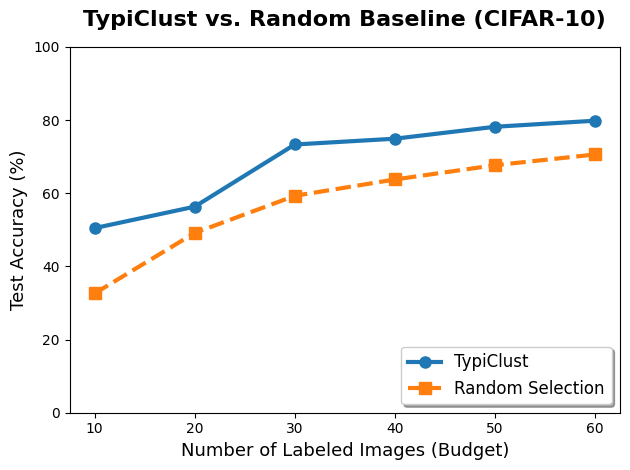

In [61]:
import matplotlib.pyplot as plt
plt.plot(budgets, accuracies, 
         marker='o', markersize=8, linewidth=3, color='#1f77b4', 
         label='TypiClust')


plt.plot(budgets, random_accuracies_linear, 
         marker='s', markersize=8, linewidth=3, color='#ff7f0e', linestyle='--',
         label='Random Selection')


plt.title('TypiClust vs. Random Baseline (CIFAR-10)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Labeled Images (Budget)', fontsize=13)
plt.ylabel('Test Accuracy (%)', fontsize=13)
plt.xticks(budgets)
plt.ylim(0, 100) # Full scale to show the true context of the performance
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("FSWSSE.png")
plt.show()

Fully Supervised Framework

In [62]:

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

full_train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, transform=train_transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, transform=test_transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)


budgets = [10, 20, 30, 40, 50, 60]
typiclust_accuracies = []

for budget in budgets:
    ids = all_typical_ids[budget]

    subset_dataset = Subset(full_train_dataset, ids)
    subset_dataset_loader = DataLoader(subset_dataset, batch_size=16, shuffle=True)


    model = resnet18()
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.025, momentum=0.9, weight_decay=5e-4)
    epochs = 100

    model.train()
    for epoch in range(epochs):
        for raw_images, labels in subset_dataset_loader:
            raw_images, labels = raw_images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(raw_images) 
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


    # testing
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            
            outputs = model(test_images) 
            _, predicted = torch.max(outputs.data, 1)
            
            total += test_labels.size(0)
            correct += (predicted == test_labels).sum().item()

    final_accuracy = 100 * correct / total
    typiclust_accuracies.append(final_accuracy)

    print(f"Final accuracy: {final_accuracy:.2f}%")

print(f"Final typiclust_accuracies: {typiclust_accuracies}%")



Files already downloaded and verified
Files already downloaded and verified
Final accuracy: 13.74%
Final accuracy: 10.94%
Final accuracy: 21.94%
Final accuracy: 24.03%
Final accuracy: 21.79%
Final accuracy: 24.96%
Final typiclust_accuracies: [13.74, 10.94, 21.94, 24.03, 21.79, 24.96]%


In [63]:
# random baseline test for fully supervised framework
random_accuracies = []

for budget in budgets:
    current_budget_accuracy = []
    for seed in seeds:
        ids = all_random_ids[budget][seed]

        subset_dataset = Subset(full_train_dataset, ids)
        subset_dataset_loader = DataLoader(subset_dataset, batch_size=16, shuffle=True)


        model = resnet18()
        model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()
        model.fc = nn.Linear(model.fc.in_features, 10)
        model = model.to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(model.parameters(), lr=0.025, momentum=0.9, weight_decay=5e-4)
        epochs = 100

        model.train()
        for epoch in range(epochs):
            for raw_images, labels in subset_dataset_loader:
                raw_images, labels = raw_images.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(raw_images) 
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()


        # testing
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for test_images, test_labels in test_loader:
                test_images, test_labels = test_images.to(device), test_labels.to(device)
                
                outputs = model(test_images) 
                _, predicted = torch.max(outputs.data, 1)
                
                total += test_labels.size(0)
                correct += (predicted == test_labels).sum().item()

        final_accuracy = 100 * correct / total
        current_budget_accuracy.append(final_accuracy)
    
    budget_mean = np.mean(current_budget_accuracy)
    random_accuracies.append(budget_mean)

print(f"random accuracy {random_accuracies}")

random accuracy [np.float64(11.309999999999999), np.float64(15.59), np.float64(17.644), np.float64(19.766), np.float64(16.968), np.float64(21.768)]


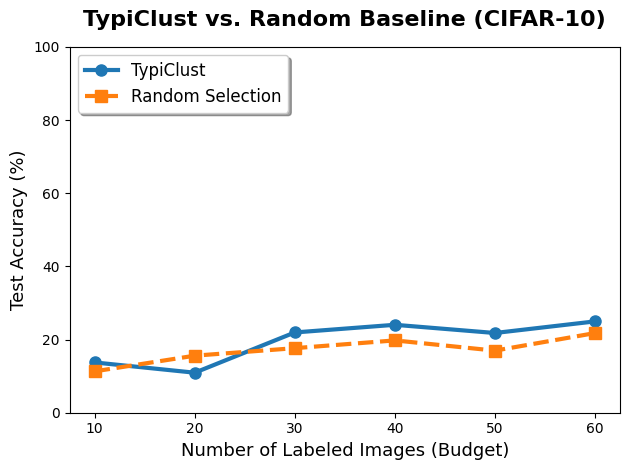

In [64]:
import matplotlib.pyplot as plt

plt.plot(budgets, typiclust_accuracies, 
         marker='o', markersize=8, linewidth=3, color='#1f77b4', 
         label='TypiClust')


plt.plot(budgets, random_accuracies, 
         marker='s', markersize=8, linewidth=3, color='#ff7f0e', linestyle='--',
         label='Random Selection')


plt.title('TypiClust vs. Random Baseline (CIFAR-10)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Labeled Images (Budget)', fontsize=13)
plt.ylabel('Test Accuracy (%)', fontsize=13)
plt.xticks(budgets)
plt.ylim(0, 100) # Full scale to show the true context of the performance
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
plt.savefig("FS.png")
plt.tight_layout()
plt.show()

Improvement Code 

In [65]:
# typiclust algorithm
budgets = [10, 20, 30, 40, 50, 60]
initial_laballed_list = []
adaptive_k_typical_ids = {}


data = torch.load(EMBEDDINGS_PATH, weights_only=False)
all_features_normalized = np.array([x.numpy() if torch.is_tensor(x) else x for x in data['features']])
all_labels = np.array([x.item() if torch.is_tensor(x) else x for x in data['labels']])

for total_budget in budgets:
  print(f"finding typical images for budget: {total_budget}")

  if total_budget <= 50:
    k_means_algorithm = KMeans(n_clusters=total_budget, random_state=42, n_init='auto')
  else: 
    k_means_algorithm = MiniBatchKMeans(n_clusters=total_budget, random_state=42, n_init='auto')


  cluster_assignments = k_means_algorithm.fit_predict(all_features_normalized)

  if len(initial_laballed_list) != 0:
    covered_clusters = set(cluster_assignments[initial_laballed_list])
  else:
    covered_clusters = set()

  all_clusters = set()
  for i in range(total_budget):
    all_clusters.add(i)

  uncovered_clusters = list(all_clusters - covered_clusters)

  # sort the uncovered clusters by highest density
  uncovered_density = []
  for cluster in uncovered_clusters:
    size = np.sum(cluster_assignments == cluster)
    uncovered_density.append((cluster, size))

  uncovered_density.sort(key=lambda x: x[1], reverse=True)

  needed_new = total_budget - len(initial_laballed_list)
  final_clusters = []
  limit = min(needed_new, len(uncovered_density))

  for i in range(limit):
    cluster_id = uncovered_density[i][0]
    final_clusters.append(cluster_id)


  # --------- typiclust --------------
  nearest = NearestNeighbors(algorithm='brute', n_jobs=-1)

  final_typical_images = []

  for i in final_clusters:
    cluster_i = np.where(cluster_assignments == i)[0]
    cluster_features = all_features_normalized[cluster_i]

    # implemented adaptive k means clustering
    n = len(cluster_features)
    

    if n <= 2:
        best_id = cluster_i[0]
    else:
      k = max(2, min(n - 1, int(np.sqrt(n))))
      nearest.set_params(n_neighbors=k)
      nearest.fit(cluster_features)
      distance, indicies = nearest.kneighbors(cluster_features)

      average_distances = distance.mean(axis=1)

      typicality_score = 1 / (average_distances + 1e-8)

      best = np.argmax(typicality_score)

      best_id = cluster_i[best]

    final_typical_images.append(int(best_id))

    print(f"Budget {total_budget} | Cluster {i} winner: Image #{best_id}")

  final_list = initial_laballed_list + final_typical_images
  adaptive_k_typical_ids[total_budget] = list(final_list)

  print("All done!")

finding typical images for budget: 10
Budget 10 | Cluster 0 winner: Image #9162
Budget 10 | Cluster 7 winner: Image #48476
Budget 10 | Cluster 1 winner: Image #48591
Budget 10 | Cluster 4 winner: Image #9178
Budget 10 | Cluster 6 winner: Image #18668
Budget 10 | Cluster 8 winner: Image #26454
Budget 10 | Cluster 3 winner: Image #11196
Budget 10 | Cluster 9 winner: Image #46075
Budget 10 | Cluster 2 winner: Image #36538
Budget 10 | Cluster 5 winner: Image #13759
All done!
finding typical images for budget: 20
Budget 20 | Cluster 13 winner: Image #18668
Budget 20 | Cluster 9 winner: Image #46075
Budget 20 | Cluster 1 winner: Image #16995
Budget 20 | Cluster 16 winner: Image #9178
Budget 20 | Cluster 18 winner: Image #1696
Budget 20 | Cluster 8 winner: Image #27954
Budget 20 | Cluster 14 winner: Image #32302
Budget 20 | Cluster 10 winner: Image #8133
Budget 20 | Cluster 2 winner: Image #7400
Budget 20 | Cluster 19 winner: Image #23817
Budget 20 | Cluster 7 winner: Image #39521
Budget 20 |

In [66]:
# linear classficiation model
# this needs to be for 10, 20, 30, 40, 50, 60 

adapative_k_accuracies = []

# initialise encoder
encoder = resnet18()
encoder.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
encoder.maxpool = nn.Identity()
encoder.fc = nn.Identity()
encoder.to(device)

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=512, shuffle=False)

for budget in budgets:
    print(f"Testing the model with the {budget} typical images...")
    ids_for_this_budget = adaptive_k_typical_ids[budget]


    X_train_numpy = all_features_normalized[ids_for_this_budget]
    y_train_numpy = all_labels[ids_for_this_budget]

    X_train = torch.tensor(X_train_numpy, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train_numpy, dtype=torch.long).to(device)

    classifier = nn.Linear(512, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        classifier.parameters(), 
        lr=2.5, 
        momentum=0.9, 
        nesterov=True,
        weight_decay=0
    )

    epochs = 200
    classifier.train()

  



    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = classifier(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()


    clean_weights = torch.load('cifar10_simclr_cleaned.pth', map_location=device, weights_only=True)
    missing, unexpected = encoder.load_state_dict(clean_weights, strict=False)
    encoder.eval()
    classifier.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            features = encoder(images)
    
            features = F.normalize(features, p=2, dim=1)
            
        
            outputs = classifier(features)
        
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    final_accuracy = 100 * correct / total

    adapative_k_accuracies.append(final_accuracy)
    print(f"Accuracy for {budget} labels: {final_accuracy:.2f}%")


print(f"\n results recorded: {adapative_k_accuracies}")

Files already downloaded and verified


c:\Users\arnav\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Testing the model with the 10 typical images...
Accuracy for 10 labels: 50.20%
Testing the model with the 20 typical images...
Accuracy for 20 labels: 59.69%
Testing the model with the 30 typical images...
Accuracy for 30 labels: 71.80%
Testing the model with the 40 typical images...
Accuracy for 40 labels: 76.24%
Testing the model with the 50 typical images...
Accuracy for 50 labels: 78.27%
Testing the model with the 60 typical images...
Accuracy for 60 labels: 80.41%

 results recorded: [50.2, 59.69, 71.8, 76.24, 78.27, 80.41]


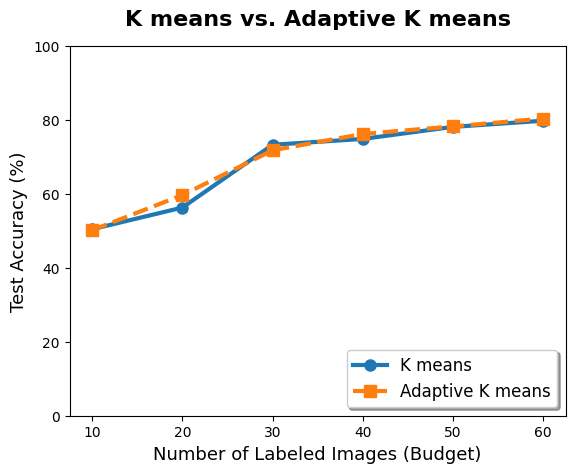

In [67]:
import matplotlib.pyplot as plt
plt.plot(budgets, accuracies, 
         marker='o', markersize=8, linewidth=3, color='#1f77b4', 
         label='K means')


plt.plot(budgets, adapative_k_accuracies, 
         marker='s', markersize=8, linewidth=3, color='#ff7f0e', linestyle='--',
         label='Adaptive K means')


plt.title('K means vs. Adaptive K means', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Labeled Images (Budget)', fontsize=13)
plt.ylabel('Test Accuracy (%)', fontsize=13)
plt.xticks(budgets)
plt.ylim(0, 100)
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)


plt.savefig("adapative.png")
plt.show()
